# Final comparison

Four questions, answered from the saved `benchmark_report_*.json` files (no inference is run here):

1. **Context vs no context**: raw function (function-only) vs CPG context, for both context strategies
   (`cpg_structural`, `multiplicative_amplification`), each with root static findings off/on.
2. **Static analyzers vs CPG context**: a static-analyzer-only predictor (vulnerable if any root
   Bandit/Dlint/Semgrep finding) vs the LLM with CPG context.
3. **Ranking strategies**: `cpg_structural` vs `multiplicative_amplification` on the main set, plus the
   full ranking sweep (all strategies vs a `dummy` baseline) from the compare-rankings runs.
4. **Fit for a secure development process on 16 GB**: covered by a separate experiment.

**Statistics for 1-3.** Every test is a paired exact McNemar test on per-sample correctness
(the two conditions are joined sample-for-sample). Holm correction is applied over the planned
comparisons, per question (`HOLM_SCOPE = "per_question"`) or over all of them (`"global"`).
**Acceptance:** a condition passes when FPR < 50 % and FNR < 50 % (point estimate); the stricter
column also requires the upper Wilson 95 % bound to be below 50 %.

**Switching setups.** Change `MODEL`, `SETUP`, `PROMPT` and `RANKING` in the config cell and re-run
all cells. The "Available runs" cells list what exists on disk.

In [1]:
import fnmatch
import functools
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import binomtest
from statsmodels.stats.contingency_tables import cochrans_q
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results").is_dir() and (p / "src").is_dir()), None
)
if ROOT is None:
    raise RuntimeError("run this notebook from inside the llm4codesec-framework checkout")
RESULTS = ROOT / "results"
pd.set_option("display.max_columns", 40, "display.width", 200, "display.max_colwidth", 80)

## Config

`SETUPS` maps each role (`function_only`, `cpg_off`, `cpg_on`, `mult_off`, `mult_on`) to a condition
directory. `plans` is searched in order; the first plan that has the condition for `MODEL`/prompt wins
(the target-split sweeps reuse the function-only report from another plan, for example).

In [2]:
# ---- what to compare -------------------------------------------------------------------------
MODEL = "gemma4-12b-it-thinking-sc7-logprobs-seeded"  # or "lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded"
SETUP = "v2_root_context"  # key of SETUPS
PROMPT = None  # None = the setup's default prompt

# Ranking sweep for question 3 (see "Available ranking sweeps" below for other options).
RANKING = dict(
    plan="context_assembler_compare_rankings_experiments/context_sizes_gemma",
    model="gemma4-12b-it-thinking",
    prompt="strict_exploitable_security",
    suffix="_4k",  # context-size suffix of the condition names; "" for plans without sizes
    baseline="dummy",
    exclude=["smoke_test"],
)

# ---- statistics ------------------------------------------------------------------------------
ALPHA = 0.05
MAX_FPR = 0.5
MAX_FNR = 0.5
HOLM_SCOPE = "per_question"  # or "global"
EXCLUDE_AUDITED_LABELS = True  # drop the 18 audited wrong labels (exclude_samples in the datasets config)
FAILED_PREDICTION = "wrong"  # failed/unparsed predictions count as errors ("wrong") or are dropped ("drop")

# ---- static-analyzer predictor (question 2) ---------------------------------------------------
SA_EXCLUDE_RULES = []  # fnmatch on rule_id, e.g. ["B101", "B113"]
SA_TOOLS = None  # None = all tools, or e.g. {"bandit", "semgrep"}

_V1_CONDS = dict(
    function_only="cleanvul_python_matched_root_findings",
    cpg_off="cpg_structural_root_findings_off",
    cpg_on="cpg_structural_root_findings_on",
    mult_off="mult_amp_root_findings_off",
    mult_on="mult_amp_root_findings_on",
)
_TARGET_CONDS = dict(
    function_only="cleanvul_python_matched_root_findings",
    cpg_off="cpg_structural_target_findings_off",
    cpg_on="cpg_structural_target_findings_on",
    mult_off="mult_amp_target_findings_off",
    mult_on="mult_amp_target_findings_on",
)
_V2_CONDS = dict(
    function_only="cleanvul_python_matched_v2_root",
    cpg_off="cpg_structural_v2_findings_off",
    cpg_on="cpg_structural_v2_findings_on",
    mult_off="mult_amp_v2_findings_off",
    mult_on="mult_amp_v2_findings_on",
)
SETUPS = {
    # v1: flat comment-stripped context, nothing marks the function under test
    "v1_flat": dict(
        plans=["static_findings_root/static_findings_root_sweep"],
        prompt="strict_exploitable_security_root_findings",
        conditions=_V1_CONDS,
    ),
    # v1 target/context split, strict prompt
    "v1_target_split": dict(
        plans=[
            "static_findings_root/static_findings_target_sweep",
            "static_findings_root/static_findings_lfm_sweep",
            "static_findings_root/static_findings_root_sweep",
        ],
        prompt="strict_exploitable_security_root_findings",
        conditions=_TARGET_CONDS,
    ),
    # v1 target/context split, v2 security prompt
    "v1_target_split_v2prompt": dict(
        plans=["static_findings_root/static_findings_v2_sweep", "static_findings_root/static_findings_lfm_sweep"],
        prompt="strict_exploitable_security_v2_root_findings",
        conditions=_TARGET_CONDS,
    ),
    # dataset v2: per-root ROOT / REFERENCE CONTEXT sections
    "v2_root_context": dict(
        plans=["root_context_v2/root_context_v2_gemma_sweep", "root_context_v2/root_context_v2_lfm_sweep"],
        prompt="root_context_security_v2_root_findings",
        conditions=_V2_CONDS,
    ),
    "v3_root_context": dict(
        plans=["root_context_v2/root_context_v3_lfm_sweep"],
        prompt="root_context_security_v3_root_findings",
        conditions=_V2_CONDS,
    ),
}
ROLE_LABELS = {
    "function_only": "function-only",
    "cpg_off": "CPG-structural",
    "cpg_on": "CPG-structural + SA findings",
    "mult_off": "mult-amp",
    "mult_on": "mult-amp + SA findings",
    "static_analyzer": "static analyzers only",
}

## Report index

In [3]:
def _index(pattern):
    rows = []
    for f in RESULTS.rglob(pattern):
        parts = f.relative_to(RESULTS).parts
        if len(parts) < 5:
            continue
        rows.append(
            dict(
                plan="/".join(parts[:-4]),
                condition=parts[-4],
                model=parts[-3],
                prompt=parts[-2],
                timestamp=f.stem.rsplit("_", 2)[-2] + "_" + f.stem.rsplit("_", 2)[-1],
                path=f,
            )
        )
    return pd.DataFrame(rows)


INDEX = _index("benchmark_report_*.json")
print(f"{len(INDEX)} benchmark reports under {RESULTS}")

1209 benchmark reports under /var/opt/llm4codesec-framework/results


### Available runs for the main setups
One row per (plan, model, prompt), with the number of distinct conditions. Use it to pick `MODEL` / `SETUP` / `PROMPT`.

In [4]:
_setup_plans = sorted({p for s in SETUPS.values() for p in s["plans"]})
(
    INDEX[INDEX.plan.isin(_setup_plans)]
    .groupby(["plan", "model", "prompt"])
    .condition.agg(n_conditions="nunique", conditions=lambda c: ", ".join(sorted(set(c))))
)

n_conditions  \
plan                                              model                                      prompt                                                       
root_context_v2/root_context_v2_gemma_sweep       gemma4-12b-it-thinking-sc7-logprobs-seeded root_context_security_v2_root_findings                   5   
root_context_v2/root_context_v2_lfm_sweep         lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded root_context_security_v2_root_findings                   5   
root_context_v2/root_context_v3_lfm_sweep         lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded root_context_security_v3_root_findings                   5   
static_findings_root/static_findings_lfm_sweep    lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded strict_exploitable_security_root_findings                5   
                                                                                             strict_exploitable_security_v2_root_findings             5   
static_findings_root/static_findings_root_sweep   gemma4-12b-it-thinking-sc7-logprobs-seeded strict_exploitable_security_root_findings                5   
static_findings_root/static_findings_target_sweep gemma4-12b-it-thinking-sc7-logprobs-seeded strict_exploitable_security_root_findings                4   
static_findings_root/static_findings_v2_sweep     gemma4-12b-it-thinking-sc7-logprobs-seeded strict_exploitable_security_v2_root_findings             5   

                                                                                                                                                                                                                conditions  
plan                                              model                                      prompt                                                                                                                         
root_context_v2/root_context_v2_gemma_sweep       gemma4-12b-it-thinking-sc7-logprobs-seeded root_context_security_v2_root_findings        cleanvul_python_matched_v2_root, cpg_structural_v2_findings_off, cpg_structu...  
root_context_v2/root_context_v2_lfm_sweep         lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded root_context_security_v2_root_findings        cleanvul_python_matched_v2_root, cpg_structural_v2_findings_off, cpg_structu...  
root_context_v2/root_context_v3_lfm_sweep         lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded root_context_security_v3_root_findings        cleanvul_python_matched_v2_root, cpg_structural_v2_findings_off, cpg_structu...  
static_findings_root/static_findings_lfm_sweep    lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded strict_exploitable_security_root_findings     cleanvul_python_matched_root_findings, cpg_structural_target_findings_off, c...  
                                                                                             strict_exploitable_security_v2_root_findings  cleanvul_python_matched_root_findings, cpg_structural_target_findings_off, c...  
static_findings_root/static_findings_root_sweep   gemma4-12b-it-thinking-sc7-logprobs-seeded strict_exploitable_security_root_findings     cleanvul_python_matched_root_findings, cpg_structural_root_findings_off, cpg...  
static_findings_root/static_findings_target_sweep gemma4-12b-it-thinking-sc7-logprobs-seeded strict_exploitable_security_root_findings     cpg_structural_target_findings_off, cpg_structural_target_findings_on, mult_...  
static_findings_root/static_findings_v2_sweep     gemma4-12b-it-thinking-sc7-logprobs-seeded strict_exploitable_security_v2_root_findings  cleanvul_python_matched_root_findings, cpg_structural_target_findings_off, c...

### Available ranking sweeps
Strategies per (plan, model, prompt, size suffix). Use it to fill `RANKING`.

In [5]:
_rk = INDEX[INDEX.plan.str.startswith("context_assembler_compare_rankings_experiments/")].copy()
_rk["suffix"] = _rk.condition.str.extract(r"(_\d+k)$", expand=False).fillna("")
_rk["strategy"] = [
    c.removeprefix("context_assembler_compare_").removesuffix(s) for c, s in zip(_rk.condition, _rk.suffix)
]
_rk.groupby(["plan", "model", "prompt", "suffix"]).strategy.agg(
    n_strategies="nunique", has_dummy=lambda s: "dummy" in set(s)
).query("n_strategies >= 3")

n_strategies  has_dummy
plan                                                                            model                            prompt                      suffix                         
context_assembler_compare_rankings_experiments/context_sizes                    gemma4-12b-it-thinking           strict_exploitable_security _16k               9       True
                                                                                                                                             _1k                9       True
                                                                                                                                             _2k                9       True
                                                                                                                                             _4k                9       True
                                                                                                                                             _8k                9       True
                                                                                gemma4-26b-a4b-gguf              strict_exploitable_security _16k               3      False
                                                                                                                                             _1k                3      False
                                                                                                                                             _2k                3      False
                                                                                                                                             _4k                3      False
                                                                                                                                             _8k                3      False
                                                                                gemma4-e4b-it                    strict_exploitable_security _16k               3      False
                                                                                                                                             _1k                3      False
                                                                                                                                             _2k                3      False
                                                                                                                                             _4k                3      False
                                                                                                                                             _8k                3      False
                                                                                qwen3-14b-gguf-thinking          strict_exploitable_security _16k               3      False
                                                                                                                                             _1k                3      False
                                                                                                                                             _2k                3      False
                                                                                                                                             _4k                3      False
                                                                                                                                             _8k                3      False
                                                                                qwen3-30b-a3b-instruct-gguf      strict_exploitable_security _16k               3      False
                                                                                                                                             _1k                3      Fal

## Loading and pairing

Join key: the CleanVul `source_row_ids` plus the label when the report stores them (all static-findings
and v2 runs), so conditions built from different dataset files pair correctly. Older compare-rankings
reports only have `sample_id`, and those IDs were re-randomized on every dataset regeneration, so they
are paired only **within one plan directory** and any ID whose label disagrees across strategies is
dropped (see `rank_load`).

In [6]:
def _row_key(rows, y):
    return f"rows={','.join(map(str, sorted(rows)))}|y={y}"


@functools.lru_cache(maxsize=None)
def load_report(path):
    with open(path) as fh:
        d = json.load(fh)
    recs = []
    for r in d["predictions"]:
        inf = r.get("inference_data") or {}
        y = int(r["true_label"])
        p = r.get("predicted_label")
        p = int(p) if r.get("is_success") and p in (0, 1) else None
        votes = {str(k): v for k, v in (inf.get("vote_counts") or {}).items()}
        n_votes = sum(votes.values())
        rows = r.get("source_row_ids")
        recs.append(
            dict(
                sample_id=r["sample_id"],
                key=_row_key(rows, y) if rows else f"id={r['sample_id']}",
                key_kind="source_rows" if rows else "sample_id",
                y=y,
                pred=p,
                vote_vuln=votes.get("1", 0) / n_votes if n_votes else np.nan,
                findings=r.get("root_static_findings"),
                prompt_tokens=inf.get("prompt_tokens"),
            )
        )
    df = pd.DataFrame(recs)
    dup = df.key.duplicated()
    if dup.any():
        warnings.warn(f"{path}: {dup.sum()} duplicate keys dropped")
        df = df[~dup]
    return df.set_index("key"), d["benchmark_info"]


def audited_keys():
    cfg = json.loads((ROOT / "src/configs/static_findings_root/datasets.json").read_text())
    ds = cfg.get("datasets", cfg)
    excl = next(v["exclude_samples"] for v in ds.values() if v.get("exclude_samples"))
    return {_row_key(e["source_row_ids"], e["label"]) for e in excl}


AUDITED = audited_keys() if EXCLUDE_AUDITED_LABELS else set()


def find_report(plans, condition, model, prompt):
    m = INDEX[
        (INDEX.condition == condition) & (INDEX.model == model) & (INDEX.prompt == prompt) & INDEX.plan.isin(plans)
    ]
    if m.empty:
        return None
    order = {p: i for i, p in enumerate(plans)}
    return m.assign(_o=m.plan.map(order)).sort_values(["_o", "timestamp"], ascending=[True, False]).iloc[0]


def load_setup(setup, model, prompt=None):
    s = SETUPS[setup]
    prompt = prompt or s["prompt"]
    frames, prov = {}, []
    for role, cond in s["conditions"].items():
        hit = find_report(s["plans"], cond, model, prompt)
        if hit is None:
            warnings.warn(f"{setup}/{role}: no report for {cond} / {model} / {prompt}")
            continue
        df, info = load_report(hit.path)
        n_raw = len(df)
        df = df[~df.index.isin(AUDITED)]
        frames[role] = df
        m = info["model"]
        prov.append(
            dict(
                role=role,
                plan=hit.plan,
                condition=cond,
                timestamp=hit.timestamp,
                n=n_raw,
                n_after_audit=len(df),
                failed=int(df.pred.isna().sum()),
                sc=m.get("self_consistency_samples"),
                seed=m.get("sampling_seed"),
                temperature=m.get("temperature"),
                prompt_sha=(info.get("prompt_template_sha256") or "")[:12],
            )
        )
    return frames, pd.DataFrame(prov).set_index("role")


def align(frames):
    """Wide frame over the keys present in every condition: y, pred_<role>, correct_<role>."""
    keys = None
    for df in frames.values():
        keys = df.index if keys is None else keys.intersection(df.index)
    wide = pd.DataFrame(index=keys)
    first = next(iter(frames.values()))
    wide["y"] = first.loc[keys, "y"]
    for role, df in frames.items():
        sub = df.loc[keys]
        if (sub.y != wide.y).any():
            raise ValueError(f"{role}: labels disagree on the joined keys")
        wide[f"pred_{role}"] = sub.pred
    if FAILED_PREDICTION == "drop":
        wide = wide.dropna(subset=[c for c in wide if c.startswith("pred_")])
    for role in frames:
        p = wide[f"pred_{role}"]
        wide[f"eff_{role}"] = p.fillna(1 - wide.y).astype(int)  # a failed prediction is an error
        wide[f"correct_{role}"] = wide[f"eff_{role}"] == wide.y
    return wide

## Metrics and tests

In [7]:
def _ci(k, n):
    if n == 0:
        return (np.nan, np.nan)
    return proportion_confint(k, n, alpha=ALPHA, method="wilson")


def binary_metrics(y, p):
    y, p = np.asarray(y), np.asarray(p)
    tp = int(((y == 1) & (p == 1)).sum())
    tn = int(((y == 0) & (p == 0)).sum())
    fp = int(((y == 0) & (p == 1)).sum())
    fn = int(((y == 1) & (p == 0)).sum())
    n, pos, neg = len(y), tp + fn, tn + fp
    prec = tp / (tp + fp) if tp + fp else np.nan
    rec = tp / pos if pos else np.nan
    denom = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    fpr_lo, fpr_hi = _ci(fp, neg)
    fnr_lo, fnr_hi = _ci(fn, pos)
    fpr, fnr = fp / neg if neg else np.nan, fn / pos if pos else np.nan
    acc_lo, acc_hi = _ci(tp + tn, n)
    return dict(
        n=n,
        accuracy=(tp + tn) / n,
        acc_lo=acc_lo,
        acc_hi=acc_hi,
        precision=prec,
        recall=rec,
        f1=2 * prec * rec / (prec + rec) if prec + rec else np.nan,
        mcc=(tp * tn - fp * fn) / denom if denom else 0.0,
        fpr=fpr,
        fpr_hi=fpr_hi,
        fnr=fnr,
        fnr_hi=fnr_hi,
        tp=tp,
        fp=fp,
        tn=tn,
        fn=fn,
        accept=bool(fpr < MAX_FPR and fnr < MAX_FNR),
        accept_strict=bool(fpr_hi < MAX_FPR and fnr_hi < MAX_FNR),
    )


def metrics_table(wide, roles):
    out = {r: binary_metrics(wide.y, wide[f"eff_{r}"]) for r in roles}
    return pd.DataFrame(out).T.rename(index=ROLE_LABELS)


def mcnemar(correct_a, correct_b):
    """Exact McNemar on paired correctness. b = only A right, c = only B right; delta = acc(B) - acc(A)."""
    a, b_ = np.asarray(correct_a, bool), np.asarray(correct_b, bool)
    n = len(a)
    b = int((a & ~b_).sum())
    c = int((~a & b_).sum())
    p = binomtest(min(b, c), b + c, 0.5).pvalue if b + c else 1.0
    delta = (c - b) / n
    se = math.sqrt(max((b + c) - (c - b) ** 2 / n, 0)) / n
    z = 1.959963984540054
    return dict(n=n, only_a=b, only_b=c, delta_acc=delta, delta_lo=delta - z * se, delta_hi=delta + z * se, p=p)


TESTS = []  # every planned comparison, collected across questions


def run_family(question, wide, pairs, labels=ROLE_LABELS):
    rows = []
    for a, b in pairs:
        if f"correct_{a}" not in wide or f"correct_{b}" not in wide:
            warnings.warn(f"{question}: skipping {a} vs {b} (condition missing)")
            continue
        r = mcnemar(wide[f"correct_{a}"], wide[f"correct_{b}"])
        rows.append(dict(question=question, A=labels.get(a, a), B=labels.get(b, b), **r))
    fam = pd.DataFrame(rows)
    if fam.empty:
        print(f"{question}: no comparison possible, every pair needs a condition this setup lacks")
        TESTS[:] = [t for t in TESTS if t["question"] != question]
        return fam
    fam["p_holm"] = multipletests(fam.p, method="holm")[1]
    fam["significant"] = fam.p_holm < ALPHA
    TESTS[:] = [t for t in TESTS if t["question"] != question] + fam.to_dict("records")
    return fam


def show_tests(fam):
    if not fam.empty:
        display(fam.style.format(precision=3, subset=["delta_acc", "delta_lo", "delta_hi", "p", "p_holm"]))


def forest(fam, title):
    if fam.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(fam) + 1.2))
    ypos = np.arange(len(fam))[::-1]
    for yv, (_, r) in zip(ypos, fam.iterrows()):
        ax.plot([r.delta_lo, r.delta_hi], [yv, yv], color="#4a4a4a", lw=2, solid_capstyle="round")
        ax.plot(
            r.delta_acc, yv, "o", ms=9, color="#0072B2", mfc="#0072B2" if r.significant else "white", mew=2
        )
        ax.annotate(f"p_holm={r.p_holm:.3g}", (r.delta_hi, yv), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=8, color="#4a4a4a")
    ax.axvline(0, color="#9a9a9a", lw=1)
    ax.set_yticks(ypos, [f"{r.B}  vs  {r.A}" for _, r in fam.iterrows()])
    ax.set_xlabel("Δ accuracy (B − A), 95 % CI   ● filled = significant after Holm")
    ax.set_title(title, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#e5e5e5", lw=0.8)
    plt.tight_layout()
    plt.show()


def error_rate_plot(mt, title):
    """FPR and FNR per condition with the upper Wilson bound; both must sit left of the limit to pass."""
    fig, ax = plt.subplots(figsize=(8, 0.45 * len(mt) + 1.4))
    ypos = np.arange(len(mt))[::-1]
    for (name, r), yv in zip(mt.iterrows(), ypos):
        for val, hi, dy, marker, color in [(r.fpr, r.fpr_hi, 0.12, "o", "#0072B2"), (r.fnr, r.fnr_hi, -0.12, "s", "#D55E00")]:
            ax.plot([val, hi], [yv + dy] * 2, color=color, lw=1.5, alpha=0.6)
            ax.plot(val, yv + dy, marker, ms=7, color=color)
        ax.annotate("pass" if r.accept else "fail", (1.0, yv), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=8, color="#4a4a4a")
    ax.axvline(MAX_FPR, color="#4a4a4a", lw=1, ls="--")
    if MAX_FNR != MAX_FPR:
        ax.axvline(MAX_FNR, color="#9a9a9a", lw=1, ls=":")
    ax.set_yticks(ypos, list(mt.index))
    ax.set_xlim(0, 1)
    ax.plot([], [], "o", color="#0072B2", label="FPR")
    ax.plot([], [], "s", color="#D55E00", label="FNR")
    ax.legend(loc="lower right", bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize=8)
    ax.set_xlabel(f"error rate (line = upper Wilson 95 % bound); limit {MAX_FPR:.0%}")
    ax.set_title(title, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#e5e5e5", lw=0.8)
    plt.tight_layout()
    plt.show()

## Load the selected setup

In [8]:
FRAMES, PROVENANCE = load_setup(SETUP, MODEL, PROMPT)
WIDE = align(FRAMES)
ROLES = list(FRAMES)
display(Markdown(f"**{SETUP}** · `{MODEL}` · prompt `{PROMPT or SETUPS[SETUP]['prompt']}` · "
                 f"{len(WIDE)} paired samples ({int(WIDE.y.sum())} vulnerable)"))
PROVENANCE

**v2_root_context** · `gemma4-12b-it-thinking-sc7-logprobs-seeded` · prompt `root_context_security_v2_root_findings` · 710 paired samples (355 vulnerable)

,plan,condition,timestamp,n,n_after_audit,failed,sc,seed,temperature,prompt_sha
role,,,,,,,,,,
function_only,root_context_v2/root_context_v2_gemma_sweep,cleanvul_python_matched_v2_root,20261001_081124,710,710,0,7,20260925,1.0,694d2a14dda6
cpg_off,root_context_v2/root_context_v2_gemma_sweep,cpg_structural_v2_findings_off,20261001_100954,710,710,0,7,20260925,1.0,694d2a14dda6
cpg_on,root_context_v2/root_context_v2_gemma_sweep,cpg_structural_v2_findings_on,20261001_120644,710,710,0,7,20260925,1.0,694d2a14dda6
mult_off,root_context_v2/root_context_v2_gemma_sweep,mult_amp_v2_findings_off,20261001_140839,710,710,0,7,20260925,1.0,694d2a14dda6
mult_on,root_context_v2/root_context_v2_gemma_sweep,mult_amp_v2_findings_on,20261001_160927,710,710,0,7,20260925,1.0,694d2a14dda6


In [9]:
METRICS = metrics_table(WIDE, ROLES)
METRICS.style.format(precision=3)

,n,accuracy,acc_lo,acc_hi,precision,recall,f1,mcc,fpr,fpr_hi,fnr,fnr_hi,tp,fp,tn,fn,accept,accept_strict
function-only,710,0.610,0.573,0.645,0.649,0.479,0.551,0.228,0.259,0.307,0.521,0.573,170,92,263,185,False,False
CPG-structural,710,0.615,0.579,0.651,0.663,0.470,0.550,0.241,0.239,0.286,0.530,0.581,167,85,270,188,False,False
CPG-structural + SA findings,710,0.618,0.582,0.653,0.668,0.470,0.552,0.248,0.234,0.281,0.530,0.581,167,83,272,188,False,False
mult-amp,710,0.608,0.572,0.644,0.646,0.479,0.550,0.225,0.262,0.310,0.521,0.573,170,93,262,185,False,False
mult-amp + SA findings,710,0.618,0.582,0.653,0.669,0.468,0.551,0.248,0.231,0.278,0.532,0.584,166,82,273,189,False,False


## Q1 · Context vs no context

Planned comparisons: function-only vs each context condition (both strategies, findings off/on), and
findings off vs on within each strategy.

,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,significant
0,Q1 context,function-only,CPG-structural,710,47,51,0.006,-0.022,0.033,0.762,1.000,False
1,Q1 context,function-only,mult-amp,710,57,56,-0.001,-0.031,0.028,1.000,1.000,False
2,Q1 context,function-only,CPG-structural + SA findings,710,54,60,0.008,-0.021,0.038,0.640,1.000,False
3,Q1 context,function-only,mult-amp + SA findings,710,51,57,0.008,-0.020,0.037,0.631,1.000,False
4,Q1 context,CPG-structural,CPG-structural + SA findings,710,32,34,0.003,-0.020,0.025,0.902,1.000,False
5,Q1 context,mult-amp,mult-amp + SA findings,710,33,40,0.010,-0.014,0.033,0.483,1.000,False


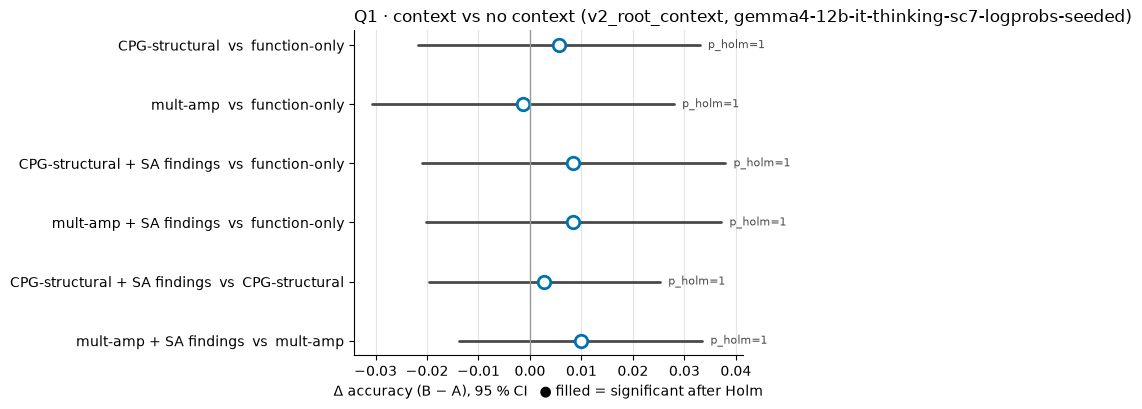

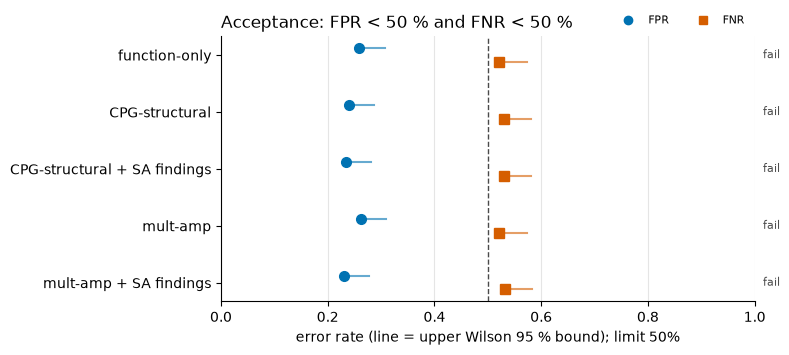

In [10]:
Q1_PAIRS = [
    ("function_only", "cpg_off"),
    ("function_only", "mult_off"),
    ("function_only", "cpg_on"),
    ("function_only", "mult_on"),
    ("cpg_off", "cpg_on"),
    ("mult_off", "mult_on"),
]
Q1 = run_family("Q1 context", WIDE, Q1_PAIRS)
show_tests(Q1)
forest(Q1, f"Q1 · context vs no context ({SETUP}, {MODEL})")
error_rate_plot(METRICS, "Acceptance: FPR < 50 % and FNR < 50 %")

## Q2 · Static analyzers vs CPG context

The static-analyzer predictor says *vulnerable* when the sample has at least one root finding (Bandit,
Dlint, Semgrep; only findings on the changed function, i.e. `is_root`), after `SA_TOOLS` /
`SA_EXCLUDE_RULES`. Findings are read from the prediction records, so they are exactly what the
`*_on` conditions showed the model.

,n,accuracy,acc_lo,acc_hi,precision,recall,f1,mcc,fpr,fpr_hi,fnr,fnr_hi,tp,fp,tn,fn,accept,accept_strict
static analyzers only,710,0.541,0.504,0.577,0.607,0.231,0.335,0.104,0.149,0.190,0.769,0.810,82,53,302,273,False,False
CPG-structural,710,0.615,0.579,0.651,0.663,0.470,0.550,0.241,0.239,0.286,0.530,0.581,167,85,270,188,False,False
mult-amp,710,0.608,0.572,0.644,0.646,0.479,0.550,0.225,0.262,0.310,0.521,0.573,170,93,262,185,False,False
CPG-structural + SA findings,710,0.618,0.582,0.653,0.668,0.470,0.552,0.248,0.234,0.281,0.530,0.581,167,83,272,188,False,False
mult-amp + SA findings,710,0.618,0.582,0.653,0.669,0.468,0.551,0.248,0.231,0.278,0.532,0.584,166,82,273,189,False,False


,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,significant
0,Q2 static analyzers,static analyzers only,CPG-structural,710,83,136,0.075,0.034,0.115,0.000,0.001,True
1,Q2 static analyzers,static analyzers only,mult-amp,710,89,137,0.068,0.026,0.109,0.002,0.002,True
2,Q2 static analyzers,static analyzers only,CPG-structural + SA findings,710,85,140,0.077,0.036,0.118,0.000,0.001,True
3,Q2 static analyzers,static analyzers only,mult-amp + SA findings,710,80,135,0.077,0.037,0.118,0.000,0.001,True


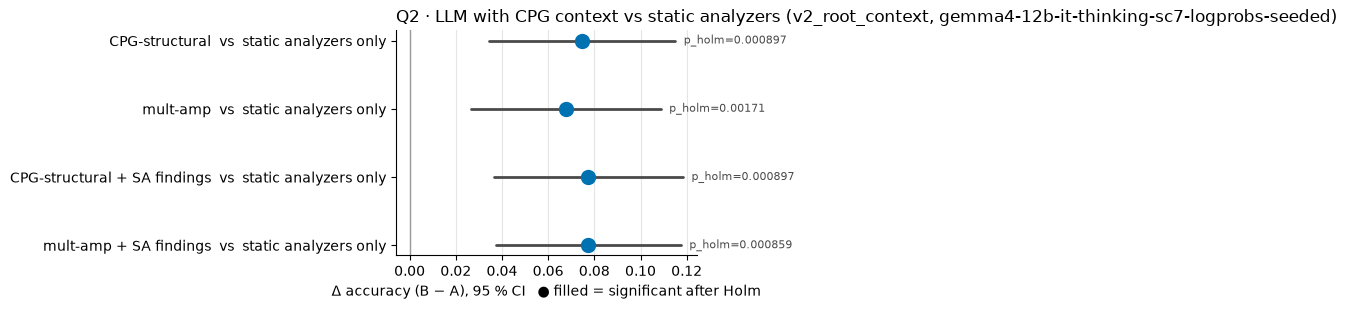

In [11]:
def sa_predict(findings):
    if not isinstance(findings, list):
        return np.nan
    kept = [
        f for f in findings
        if (SA_TOOLS is None or f.get("tool") in SA_TOOLS)
        and not any(fnmatch.fnmatch(str(f.get("rule_id")), pat) for pat in SA_EXCLUDE_RULES)
    ]
    return int(bool(kept))


_src = next((r for r in ["cpg_on", "mult_on", "cpg_off", "mult_off", "function_only"]
             if r in FRAMES and FRAMES[r].findings.notna().any()), None)
if _src is None:
    raise RuntimeError("no condition in this setup stores root_static_findings")
_sa = FRAMES[_src].loc[WIDE.index, "findings"].map(sa_predict)
if _sa.isna().any():
    warnings.warn(f"{_sa.isna().sum()} samples without stored findings are treated as 'no finding'")
WIDE["eff_static_analyzer"] = _sa.fillna(0).astype(int)
WIDE["correct_static_analyzer"] = WIDE.eff_static_analyzer == WIDE.y

Q2_PAIRS = [("static_analyzer", r) for r in ["cpg_off", "mult_off", "cpg_on", "mult_on"]]
Q2 = run_family("Q2 static analyzers", WIDE, Q2_PAIRS)
display(metrics_table(WIDE, ["static_analyzer"] + [b for _, b in Q2_PAIRS if b in FRAMES]).style.format(precision=3))
show_tests(Q2)
forest(Q2, f"Q2 · LLM with CPG context vs static analyzers ({SETUP}, {MODEL})")

Descriptive only (not part of the Holm family): each analyzer on its own, and which rules fire most.

In [12]:
_per_tool = {}
_all_findings = FRAMES[_src].loc[WIDE.index, "findings"]
for tool in ["bandit", "dlint", "semgrep"]:
    p = _all_findings.map(lambda fs: int(any(f.get("tool") == tool for f in fs or [])))
    _per_tool[tool] = binary_metrics(WIDE.y, p)
display(pd.DataFrame(_per_tool).T[["n", "accuracy", "precision", "recall", "fpr", "fnr", "mcc", "accept"]]
        .style.format(precision=3))

_rules = pd.DataFrame(
    [dict(tool=f.get("tool"), rule_id=f.get("rule_id"), y=y)
     for fs, y in zip(_all_findings, WIDE.y) for f in (fs or [])]
)
if not _rules.empty:
    display(_rules.groupby(["tool", "rule_id"]).y.agg(findings="size", on_vulnerable="sum")
            .assign(share_on_vulnerable=lambda t: t.on_vulnerable / t.findings)
            .sort_values("findings", ascending=False).head(15))

,n,accuracy,precision,recall,fpr,fnr,mcc,accept
bandit,710,0.538,0.631,0.183,0.107,0.817,0.108,False
dlint,710,0.527,0.634,0.127,0.073,0.873,0.089,False
semgrep,710,0.514,0.600,0.085,0.056,0.915,0.055,False


findings  on_vulnerable  share_on_vulnerable
tool    rule_id                                                                                                                       
bandit  B113                                                                                    51             26             0.509804
semgrep python.lang.security.audit.insecure-transport.requests.request-with-http.requ...        36             18             0.500000
        python.lang.security.audit.subprocess-shell-true.subprocess-shell-true                  24             15             0.625000
bandit  B602                                                                                    23             14             0.608696
        B608                                                                                    23             21             0.913043
dlint   DUO116                                                                                  23             14             0.608696
        DUO109                                                                                  22             14             0.636364
bandit  B603                                                                                    20              6             0.300000
semgrep python.flask.security.injection.ssrf-requests.ssrf-requests                             20             10             0.500000
bandit  B605                                                                                    17              8             0.470588
        B202                                                                                    13              7             0.538462
        B506                                                                                    12             11             0.916667
semgrep python.lang.security.audit.logging.logger-credential-leak.python-logger-crede...        11              6             0.545455
dlint   DUO102                                                                                  11              6             0.545455
        DUO106                                                                                  11              4             0.363636

## Q3 · Ranking strategies

**3a, main set.** `cpg_structural` vs `multiplicative_amplification`, findings off and on (same pairing as Q1).

In [13]:
Q3A = run_family("Q3a ranking (main set)", WIDE, [("cpg_off", "mult_off"), ("cpg_on", "mult_on")])
show_tests(Q3A)

,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,significant
0,Q3a ranking (main set),CPG-structural,mult-amp,710,39,34,-0.007,-0.031,0.017,0.640,1.000,False
1,Q3a ranking (main set),CPG-structural + SA findings,mult-amp + SA findings,710,38,38,0.000,-0.024,0.024,1.000,1.000,False


**3b, full ranking sweep** (`RANKING`). Cochran's Q tests whether any strategy differs at all; the
planned comparisons are every strategy vs `RANKING["baseline"]`, Holm-corrected. These runs predate
`source_row_ids`, so they pair by `sample_id` inside one plan directory, and IDs whose label differs
between strategies are dropped (a sign of mixed dataset generations).

`context_assembler_compare_rankings_experiments/context_sizes_gemma` · `gemma4-12b-it-thinking` · suffix `_4k` · 376 paired samples, 9 strategies · 0 label conflicts

,timestamp,n,n_reruns,sc
strategy,,,,
cpg_structural,20260626_012142,376,1,1
current,20260626_001652,376,1,1
current_default,20260626_010435,376,1,1
depth_repeats_context,20260626_002613,376,1,1
dummy,20260626_003628,376,1,1
evidence_budgeted,20260626_012934,376,1,1
multiplicative_boost,20260626_004548,376,1,1
multiplicative_boost_default,20260626_011354,376,1,1
random_picking,20260626_005509,376,1,1


,n,accuracy,acc_lo,acc_hi,precision,recall,mcc,fpr,fnr,accept,accept_strict
evidence_budgeted,376,0.606,0.556,0.654,0.601,0.633,0.213,0.420,0.367,True,True
multiplicative_boost,376,0.588,0.537,0.636,0.579,0.644,0.177,0.468,0.356,True,False
current_default,376,0.585,0.535,0.634,0.570,0.691,0.174,0.521,0.309,False,False
multiplicative_boost_default,376,0.582,0.532,0.631,0.571,0.660,0.167,0.495,0.340,True,False
cpg_structural,376,0.577,0.527,0.626,0.574,0.601,0.154,0.447,0.399,True,False
dummy,376,0.574,0.524,0.623,0.566,0.638,0.150,0.489,0.362,True,False
current,376,0.566,0.516,0.616,0.555,0.676,0.136,0.543,0.324,False,False
random_picking,376,0.548,0.497,0.597,0.543,0.601,0.096,0.505,0.399,False,False
depth_repeats_context,376,0.537,0.487,0.587,0.534,0.590,0.075,0.516,0.410,False,False


Cochran's Q = 9.38, df = 8, p = 0.312

,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,significant
0,Q3b ranking sweep,dummy,cpg_structural,376,59,60,0.003,-0.054,0.060,1.000,1.000,False
1,Q3b ranking sweep,dummy,current,376,52,49,-0.008,-0.060,0.044,0.842,1.000,False
2,Q3b ranking sweep,dummy,current_default,376,50,54,0.011,-0.043,0.064,0.769,1.000,False
3,Q3b ranking sweep,dummy,depth_repeats_context,376,59,45,-0.037,-0.090,0.016,0.202,1.000,False
4,Q3b ranking sweep,dummy,evidence_budgeted,376,53,65,0.032,-0.025,0.088,0.311,1.000,False
5,Q3b ranking sweep,dummy,multiplicative_boost,376,54,59,0.013,-0.042,0.069,0.707,1.000,False
6,Q3b ranking sweep,dummy,multiplicative_boost_default,376,47,50,0.008,-0.043,0.059,0.839,1.000,False
7,Q3b ranking sweep,dummy,random_picking,376,59,49,-0.027,-0.081,0.028,0.387,1.000,False


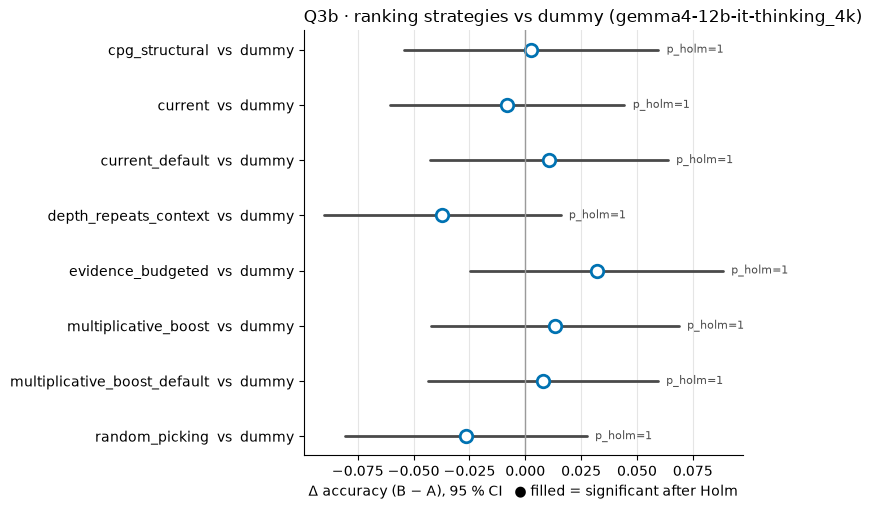

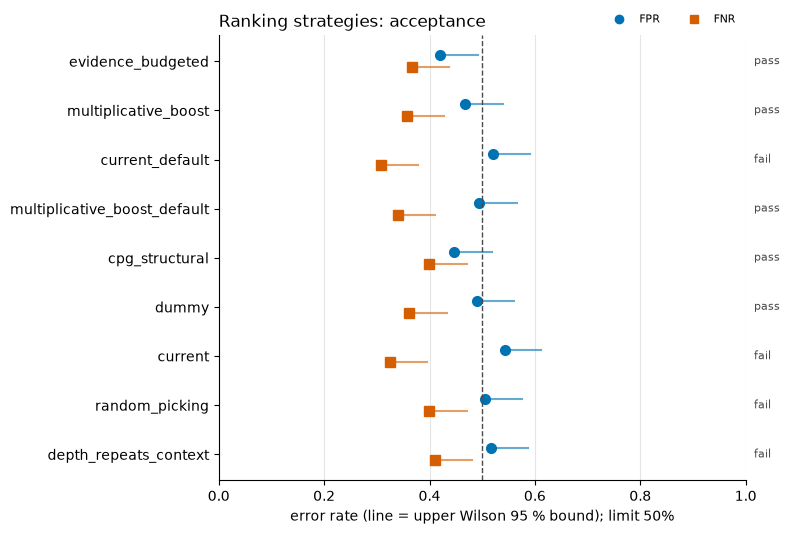

In [14]:
def rank_load(cfg):
    m = INDEX[(INDEX.plan == cfg["plan"]) & (INDEX.model == cfg["model"]) & (INDEX.prompt == cfg["prompt"])]
    frames, prov = {}, []
    for cond, g in m.groupby("condition"):
        if cfg["suffix"] and not cond.endswith(cfg["suffix"]):
            continue
        if not cfg["suffix"] and pd.Series([cond]).str.contains(r"_\d+k$").iloc[0]:
            continue
        strat = cond.removeprefix("context_assembler_compare_").removesuffix(cfg["suffix"])
        if strat in cfg.get("exclude", []):
            continue
        hit = g.sort_values("timestamp").iloc[-1]
        df, info = load_report(hit.path)
        frames[strat] = df
        prov.append(dict(strategy=strat, timestamp=hit.timestamp, n=len(df), n_reruns=len(g),
                         sc=info["model"].get("self_consistency_samples")))
    # labels must agree per key across strategies
    lab = pd.concat({s: f.y for s, f in frames.items()}, axis=1)
    conflict = lab.nunique(axis=1) > 1
    if conflict.any():
        warnings.warn(f"{conflict.sum()} sample ids have conflicting labels across strategies; dropped")
    keep = lab.index[~conflict & lab.notna().all(axis=1)]
    frames = {s: f.loc[f.index.intersection(keep)] for s, f in frames.items()}
    return frames, pd.DataFrame(prov).set_index("strategy"), int(conflict.sum())


RK_FRAMES, RK_PROV, RK_CONFLICTS = rank_load(RANKING)
RK_WIDE = align(RK_FRAMES)
RK = list(RK_FRAMES)
display(Markdown(f"`{RANKING['plan']}` · `{RANKING['model']}` · suffix `{RANKING['suffix'] or '-'}` · "
                 f"{len(RK_WIDE)} paired samples, {len(RK)} strategies"
                 + (f" · **{RK_CONFLICTS} ids dropped for conflicting labels: this sweep mixes dataset "
                    "generations, so even the kept ids may not pair the same code. Prefer a sweep with 0.**"
                    if RK_CONFLICTS else " · 0 label conflicts")))
display(RK_PROV)
RK_METRICS = metrics_table(RK_WIDE, RK).sort_values("accuracy", ascending=False)
display(RK_METRICS[["n", "accuracy", "acc_lo", "acc_hi", "precision", "recall", "mcc", "fpr", "fnr", "accept",
                    "accept_strict"]].style.format(precision=3))

_q = cochrans_q(RK_WIDE[[f"correct_{s}" for s in RK]].astype(int).values)
display(Markdown(f"Cochran's Q = {_q.statistic:.2f}, df = {len(RK) - 1}, p = {_q.pvalue:.3g}"))

base = RANKING["baseline"]
Q3B = run_family("Q3b ranking sweep", RK_WIDE, [(base, s) for s in RK if s != base], labels={})
show_tests(Q3B)
forest(Q3B, f"Q3b · ranking strategies vs {base} ({RANKING['model']}{RANKING['suffix']})")
error_rate_plot(RK_METRICS, "Ranking strategies: acceptance")

## Summary of Q1-Q3
Holm correction over the scope chosen by `HOLM_SCOPE`. Q3a and Q3b are separate families when the scope
is per question.

In [15]:
SUMMARY = pd.DataFrame(TESTS, columns=["question", "A", "B", "n", "only_a", "only_b", "delta_acc", "delta_lo",
                                       "delta_hi", "p"])
if HOLM_SCOPE == "global":
    SUMMARY["p_holm"] = multipletests(SUMMARY.p, method="holm")[1]
else:
    SUMMARY["p_holm"] = SUMMARY.groupby("question").p.transform(lambda p: multipletests(p, method="holm")[1])
SUMMARY["significant"] = SUMMARY.p_holm < ALPHA
SUMMARY["verdict"] = np.where(
    ~SUMMARY.significant, "no significant difference",
    np.where(SUMMARY.delta_acc > 0, "B better", "A better"),
)
display(SUMMARY[["question", "A", "B", "n", "only_a", "only_b", "delta_acc", "delta_lo", "delta_hi", "p",
                 "p_holm", "verdict"]].style.format(precision=3, subset=["delta_acc", "delta_lo", "delta_hi",
                                                                         "p", "p_holm"]))
_acc = pd.concat([METRICS.assign(set=SETUP), RK_METRICS.assign(set="ranking sweep")])
display(_acc[["set", "n", "accuracy", "fpr", "fpr_hi", "fnr", "fnr_hi", "accept", "accept_strict"]]
        .style.format(precision=3))

,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,verdict
0,Q1 context,function-only,CPG-structural,710,47,51,0.006,-0.022,0.033,0.762,1.000,no significant difference
1,Q1 context,function-only,mult-amp,710,57,56,-0.001,-0.031,0.028,1.000,1.000,no significant difference
2,Q1 context,function-only,CPG-structural + SA findings,710,54,60,0.008,-0.021,0.038,0.640,1.000,no significant difference
3,Q1 context,function-only,mult-amp + SA findings,710,51,57,0.008,-0.020,0.037,0.631,1.000,no significant difference
4,Q1 context,CPG-structural,CPG-structural + SA findings,710,32,34,0.003,-0.020,0.025,0.902,1.000,no significant difference
5,Q1 context,mult-amp,mult-amp + SA findings,710,33,40,0.010,-0.014,0.033,0.483,1.000,no significant difference
6,Q2 static analyzers,static analyzers only,CPG-structural,710,83,136,0.075,0.034,0.115,0.000,0.001,B better
7,Q2 static analyzers,static analyzers only,mult-amp,710,89,137,0.068,0.026,0.109,0.002,0.002,B better
8,Q2 static analyzers,static analyzers only,CPG-structural + SA findings,710,85,140,0.077,0.036,0.118,0.000,0.001,B better
9,Q2 static analyzers,static analyzers only,mult-amp + SA findings,710,80,135,0.077,0.037,0.118,0.000,0.001,B better


,set,n,accuracy,fpr,fpr_hi,fnr,fnr_hi,accept,accept_strict
function-only,v2_root_context,710,0.610,0.259,0.307,0.521,0.573,False,False
CPG-structural,v2_root_context,710,0.615,0.239,0.286,0.530,0.581,False,False
CPG-structural + SA findings,v2_root_context,710,0.618,0.234,0.281,0.530,0.581,False,False
mult-amp,v2_root_context,710,0.608,0.262,0.310,0.521,0.573,False,False
mult-amp + SA findings,v2_root_context,710,0.618,0.231,0.278,0.532,0.584,False,False
evidence_budgeted,ranking sweep,376,0.606,0.420,0.492,0.367,0.438,True,True
multiplicative_boost,ranking sweep,376,0.588,0.468,0.539,0.356,0.427,True,False
current_default,ranking sweep,376,0.585,0.521,0.592,0.309,0.378,False,False
multiplicative_boost_default,ranking sweep,376,0.582,0.495,0.566,0.340,0.411,True,False
cpg_structural,ranking sweep,376,0.577,0.447,0.518,0.399,0.470,True,False


## Q4 · Fit for a secure development process on 16 GB

Covered by a separate experiment.